# PHASE 7 - GRU Time-Series Model

This notebook trains a small GRU model on CPU to predict bike demand from the previous 24 observations and their engineered features.

Leakage prevention: scalers are fit only on the training split, sequences preserve chronological order, and validation/test sequences use only preceding context. Training data is not shuffled.

In [ ]:
# Nhập các thư viện cần thiết
from pathlib import Path  # Làm việc với đường dẫn file
from time import perf_counter  # Đo thời gian thực thi
import os  # Tương tác với hệ điều hành
import pickle  # Lưu và tải các object Python

# Tắt GPU (chỉ sử dụng CPU)
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"

import matplotlib.pyplot as plt  # Vẽ đồ thị
import numpy as np  # Xử lý mảng số học
import pandas as pd  # Xử lý dữ liệu
import tensorflow as tf  # Thư viện deep learning
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score  # Các hàm tính metrics
from sklearn.preprocessing import StandardScaler  # Chuẩn hóa dữ liệu

# Đặt seed cho TensorFlow để kết quả có thể tái lập
tf.keras.utils.set_random_seed(42)

# Cố gắng tắt GPU nếu có
try:
    tf.config.set_visible_devices([], "GPU")
except RuntimeError:
    pass

# Hàm tìm thư mục gốc của project
def find_project_root():
    # Kiểm tra từng vị trí xem có file train.csv không
    for candidate in [Path("."), Path("..")]:
        if (candidate / "data/processed/train.csv").exists():
            return candidate
    # Nếu không tìm thấy, báo lỗi
    raise FileNotFoundError("Run PHASE 3 first to create data/processed/train.csv.")

# Tìm và lưu đường dẫn thư mục gốc
project_root = find_project_root()

# Định nghĩa các đường dẫn thư mục cần dùng
processed_dir = project_root / "data/processed"  # Thư mục dữ liệu đã xử lý
metrics_dir = project_root / "results/metrics"  # Thư mục lưu metrics
figures_dir = project_root / "results/figures"  # Thư mục lưu hình
models_dir = project_root / "models"  # Thư mục lưu mô hình

# Tạo các thư mục nếu chưa tồn tại
for directory in [metrics_dir, figures_dir, models_dir]:
    directory.mkdir(parents=True, exist_ok=True)

In [ ]:
# Hàm tải dữ liệu từ file CSV
def load_split(name):
    return pd.read_csv(processed_dir / f"{name}.csv", parse_dates=["timestamp", "dteday"])

# Tải 3 tập dữ liệu từ PHASE 3
train_df = load_split("train")  # Dữ liệu huấn luyện
validation_df = load_split("validation")  # Dữ liệu xác thực
test_df = load_split("test")  # Dữ liệu kiểm tra

# === CHUẨN BỊ DỮ LIỆU ===
target_column = "cnt"  # Cột mục tiêu: số lượng xe đạp được thuê

# Các cột cần loại bỏ
excluded_columns = {target_column, "instant", "dteday", "timestamp", "casual", "registered"}

# Lấy tất cả cột features (trừ các cột loại bỏ)
feature_columns = [column for column in train_df.columns if column not in excluded_columns]

# Độ dài sequence: mô hình GRU sẽ nhìn lại 24 quan sát trước đó
sequence_length = 24

# Kiểm tra dữ liệu theo thứ tự thời gian (tránh data leakage)
assert train_df["timestamp"].max() < validation_df["timestamp"].min()
assert validation_df["timestamp"].max() < test_df["timestamp"].min()

# In thông tin về dữ liệu
print(f"Project root: {project_root.resolve()}")
print(f"Features: {len(feature_columns)}")  # Số lượng features
print(f"Rows train/validation/test: {len(train_df)}/{len(validation_df)}/{len(test_df)}")  # Kích thước các tập

Project root: D:\bike-demand-prediction
Features: 27
Rows train/validation/test: 12047/2582/2582


## Scale using training data only

In [ ]:
# === CHUẨN HÓA DỮ LIỆU (CHỈ DÙNG TẬP TRAIN) ===
# Tạo 2 scaler: một cho features, một cho target
feature_scaler = StandardScaler()  # Chuẩn hóa features: (X - mean) / std
target_scaler = StandardScaler()  # Chuẩn hóa target

# Fit scaler trên tập train (KHÔNG dùng validation và test)
# fit_transform: vừa fit vừa transform lúc đó
# transform: chỉ transform mà không thay đổi scaler
X_train_scaled = feature_scaler.fit_transform(train_df[feature_columns])  # Fit trên train và transform
X_validation_scaled = feature_scaler.transform(validation_df[feature_columns])  # Chỉ transform validation
X_test_scaled = feature_scaler.transform(test_df[feature_columns])  # Chỉ transform test

# Chuẩn hóa target
y_train_scaled = target_scaler.fit_transform(train_df[[target_column]]).ravel()  # Fit trên train
y_validation_scaled = target_scaler.transform(validation_df[[target_column]]).ravel()  # Transform validation
y_test_scaled = target_scaler.transform(test_df[[target_column]]).ravel()  # Transform test

# In thông báo
print("Feature and target scalers fit on train only.")

Feature and target scalers fit on train only.


## Build chronological sequences

For validation and test, the preceding 24 scaled rows are supplied as context. These rows come from an earlier split and do not include future observations.

In [ ]:
# === XÂY DỰNG SEQUENCES CHO MỌ HÌNH LSTM/GRU ===
# Hàm tạo sequences từ dữ liệu
# Input: 24 quan sát trước đó
# Output: giá trị tiếp theo cần dự đoán
def make_sequences(features, targets, sequence_length):
    sequence_features = []  # Danh sách lưu features sequences
    sequence_targets = []  # Danh sách lưu targets tương ứng
    
    # Vòng lặp: bắt đầu từ sequence_length (vì cần 24 quan sát trước đó)
    for index in range(sequence_length, len(features)):
        # Lấy 24 quan sát trước đó (từ index-24 đến index)
        sequence_features.append(features[index - sequence_length:index])
        # Lấy giá trị tiếp theo (tại index)
        sequence_targets.append(targets[index])
    
    # Chuyển thành numpy array
    return np.asarray(sequence_features), np.asarray(sequence_targets)

# === TẠO SEQUENCES CHO TẬP TRAIN ===
# Train sequences được tạo trực tiếp từ train data
X_train_seq, y_train_seq = make_sequences(X_train_scaled, y_train_scaled, sequence_length)

# === TẠO SEQUENCES CHO TẬP VALIDATION ===
# Để tránh rò rỉ dữ liệu, validation sequences cần bao gồm ngữ cảnh (context)
# Ngữ cảnh = 24 quan sát cuối cùng của train (để có đủ context cho quan sát đầu validation)
validation_context_X = np.vstack([X_train_scaled[-sequence_length:], X_validation_scaled])  # Ghép train cuối + validation
validation_context_y = np.concatenate([y_train_scaled[-sequence_length:], y_validation_scaled])  # Ghép train cuối + validation
X_validation_seq, y_validation_seq = make_sequences(validation_context_X, validation_context_y, sequence_length)

# === TẠO SEQUENCES CHO TẬP TEST ===
# Tương tự, test sequences cần bao gồm ngữ cảnh
# Ngữ cảnh = 24 quan sát cuối cùng của validation (để có đủ context cho quan sát đầu test)
test_context_X = np.vstack([X_validation_scaled[-sequence_length:], X_test_scaled])  # Ghép validation cuối + test
test_context_y = np.concatenate([y_validation_scaled[-sequence_length:], y_test_scaled])  # Ghép validation cuối + test
X_test_seq, y_test_seq = make_sequences(test_context_X, test_context_y, sequence_length)

# === KIỂM TRA KÍCH THƯỚC ===
# Số sequences trong train phải bằng số hàng train - sequence_length
assert len(X_train_seq) == len(train_df) - sequence_length
# Số sequences trong validation phải bằng số hàng validation (có đủ context)
assert len(X_validation_seq) == len(validation_df)
# Số sequences trong test phải bằng số hàng test (có đủ context)
assert len(X_test_seq) == len(test_df)

# In kích thước sequences
print(f"Sequence shapes: train={X_train_seq.shape}, validation={X_validation_seq.shape}, test={X_test_seq.shape}")

Sequence shapes: train=(12023, 24, 27), validation=(2582, 24, 27), test=(2582, 24, 27)


In [ ]:
# === XÂY DỰNG MÔ HÌNH NEURAL NETWORK ===
# Sequential: tạo mô hình với các layer xếp chồng lên nhau
model = tf.keras.Sequential([
    # Layer Input: định nghĩa kích thước input
    # shape=(sequence_length, len(feature_columns)) = (24, số features)
    tf.keras.layers.Input(shape=(sequence_length, len(feature_columns))),
    
    # Layer GRU: Gated Recurrent Unit (xử lý sequences)
    # 32: số lượng units (neurons) trong GRU
    # GRU xem lại tất cả 24 quan sát trước đó và tạo một vectơ 32 chiều
    tf.keras.layers.GRU(32),
    
    # Layer Dense (fully connected): xử lý output của GRU
    # 16: số neurons
    # activation="relu": hàm kích hoạt ReLU (max(0, x))
    tf.keras.layers.Dense(16, activation="relu"),
    
    # Layer Dense output: dự đoán giá trị (1 neuron vì là regression)
    tf.keras.layers.Dense(1),
])

# Biên soạn (compile) mô hình
# optimizer: Adam - tối ưu hóa weights dựa trên gradients
# learning_rate=0.001: tốc độ học (bước nhảy khi cập nhật weights)
# loss="mse": Mean Squared Error (mục tiêu tối thiểu)
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), loss="mse")

# Early Stopping callback: dừng huấn luyện nếu validation loss không cải thiện
# monitor="val_loss": theo dõi validation loss
# patience=4: nếu không cải thiện trong 4 epoch liên tiếp thì dừng
# restore_best_weights=True: khôi phục weights tốt nhất
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=4, restore_best_weights=True
)

# Bắt đầu đo thời gian
start_time = perf_counter()

# Huấn luyện (fit) mô hình
history = model.fit(
    X_train_seq, y_train_seq,  # Dữ liệu huấn luyện (features, targets)
    validation_data=(X_validation_seq, y_validation_seq),  # Dữ liệu xác thực
    epochs=30,  # Số lần lặp qua toàn bộ dữ liệu
    batch_size=64,  # Số mẫu xử lý cùng lúc
    shuffle=False,  # Không xáo trộn (giữ thứ tự thời gian)
    callbacks=[early_stopping],  # Sử dụng early stopping
    verbose=1,  # In chi tiết quá trình huấn luyện
)

# Kết thúc đo thời gian
training_time = perf_counter() - start_time

# In thông tin huấn luyện
print(f"Training time: {training_time:.2f} seconds")
print(f"Epochs completed: {len(history.history['loss'])}")

Epoch 1/30
188/188 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.4585 - val_loss: 0.6098
Epoch 2/30
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.1975 - val_loss: 0.3855
Epoch 3/30
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.1285 - val_loss: 0.2865
Epoch 4/30
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.1026 - val_loss: 0.2472
Epoch 5/30
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0873 - val_loss: 0.2196
Epoch 6/30
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0782 - val_loss: 0.2046
Epoch 7/30
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0721 - val_loss: 0.1954
Epoch 8/30
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0679 - val_loss: 0.1886
Epoch 9/30
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0643 - val_loss: 0.1826
Epoch 10/30
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0617 - val_loss: 0.1786
Epoch 11/30
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0594 - val_loss: 0.1758
Epoch 12/30
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/s

In [ ]:
# === TÍNH CÁC METRICS ===
# Hàm tính metrics: cần chuyển về giá trị gốc (inverse_transform) trước khi tính
def calculate_metrics(y_true_scaled, predictions_scaled, split_name):
    # Chuyển từ giá trị đã chuẩn hóa về giá trị gốc
    y_true = target_scaler.inverse_transform(y_true_scaled.reshape(-1, 1)).ravel()  # Giá trị thực tế gốc
    predictions = target_scaler.inverse_transform(predictions_scaled.reshape(-1, 1)).ravel()  # Dự đoán gốc
    
    return {
        "model": "GRU",  # Tên model
        "split": split_name,  # Tên tập (validation hoặc test)
        "MAE": mean_absolute_error(y_true, predictions),  # Sai số tuyệt đối trung bình
        "RMSE": mean_squared_error(y_true, predictions) ** 0.5,  # Căn bậc hai sai số bình phương trung bình
        "R2": r2_score(y_true, predictions),  # Tỷ lệ phương sai được giải thích
        "Training Time": training_time,  # Thời gian huấn luyện
    }

# Dự đoán trên tập validation (không in chi tiết)
validation_predictions_scaled = model.predict(X_validation_seq, verbose=0).ravel()

# Dự đoán trên tập test
test_predictions_scaled = model.predict(X_test_seq, verbose=0).ravel()

# Tính metrics cho cả validation và test
metrics = pd.DataFrame([
    calculate_metrics(y_validation_seq, validation_predictions_scaled, "validation"),
    calculate_metrics(y_test_seq, test_predictions_scaled, "test"),
])

# Hiển thị metrics (làm tròn 4 chữ số thập phân)
display(metrics.round(4))

# Lưu metrics vào file CSV
metrics.to_csv(metrics_dir / "gru_metrics.csv", index=False)

,model,split,MAE,RMSE,R2,Training Time
0,GRU,validation,46.5281,64.1135,0.9183,27.8381
1,GRU,test,48.2675,69.0899,0.8957,27.8381


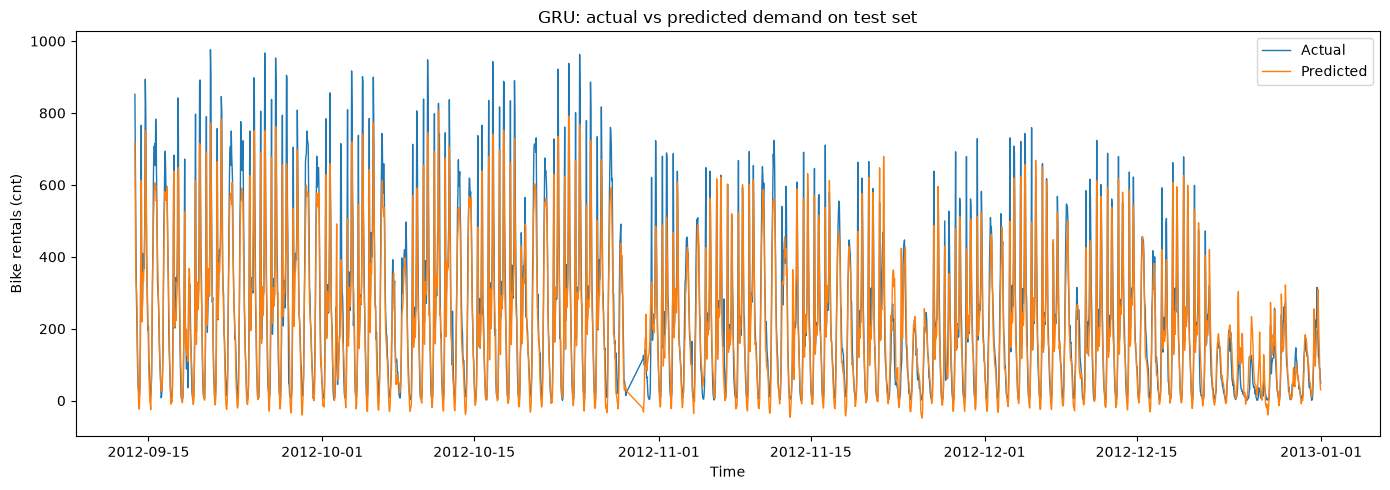

Saved model to: ..\models\gru.keras


In [ ]:
# === VẼ SO SÁNH DỰ ĐOÁN VỚI GIÁ TRỊ THỰC TẾ ===
# Chuyển dự đoán từ giá trị chuẩn hóa về giá trị gốc
test_actual = target_scaler.inverse_transform(y_test_seq.reshape(-1, 1)).ravel()  # Giá trị thực tế gốc
test_predictions = target_scaler.inverse_transform(test_predictions_scaled.reshape(-1, 1)).ravel()  # Dự đoán gốc

# Tạo DataFrame so sánh
comparison = pd.DataFrame({
    "timestamp": test_df["timestamp"].to_numpy(),  # Thời gian
    "actual": test_actual,  # Giá trị thực tế
    "predicted": test_predictions,  # Giá trị dự đoán
})

# Tạo biểu đồ với kích thước 14x5 inch
plt.figure(figsize=(14, 5))

# Vẽ đường thực tế
plt.plot(comparison["timestamp"], comparison["actual"], label="Actual", linewidth=1)

# Vẽ đường dự đoán
plt.plot(comparison["timestamp"], comparison["predicted"], label="Predicted", linewidth=1)

# Đặt tiêu đề và nhãn trục
plt.title("GRU: actual vs predicted demand on test set")
plt.xlabel("Time")
plt.ylabel("Bike rentals (cnt)")

# Thêm chú thích
plt.legend()

# Điều chỉnh layout
plt.tight_layout()

# Lưu biểu đồ
plt.savefig(figures_dir / "gru_actual_vs_predicted.png", dpi=150)

# Hiển thị biểu đồ
plt.show()

# === LƯU MÔ HÌNH ===
# Lưu model Keras (.keras format)
model_path = models_dir / "gru.keras"
model.save(model_path)

# Lưu các scalers và thông tin khác cần dùng khi dự đoán lại
with (models_dir / "gru_preprocessing.pkl").open("wb") as scaler_file:
    pickle.dump({
        "feature_scaler": feature_scaler,  # Scaler cho features
        "target_scaler": target_scaler,  # Scaler cho target
        "feature_columns": feature_columns,  # Danh sách features
        "sequence_length": sequence_length,  # Độ dài sequences
    }, scaler_file)

# In thông báo đã lưu
print(f"Saved model to: {model_path}")

## Phase 7 conclusion

The CPU GRU model uses train-only scaling, chronological sequences, and early stopping. Its metrics can now be compared with the classical models in PHASE 8.